In [57]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
from datetime import date

import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter

import eurostat #python wrapper for taking data. 
import time

In [58]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals'

In [59]:
import os
os.chdir(Share_point)

In [60]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\LNG terminals'

In [61]:
Points_APIs = pd.read_excel(r'Dataproviders 09.05.2023.xlsx',sheet_name='LNG terminals')

### key for version 6 and 7 of the API calls GIE

In [62]:
headers = {"x-key":"d8561648296cb38e6c400823755689941530"} # After July 4th 2022

### Restart here

In [73]:
d1 = '2015-01-01'
d2 = '2015-12-31' # To change in the new year

In [74]:
dates = []
sendOut = []
stored = []
max_storage = []
max_sendout =[]
country = []
Name = []

for item in range(len(Points_APIs)):
        url = Points_APIs.iloc[item,3]+'&from={}&to={}&size=300'.format(d1,d2)
        try:
            r = requests.get(url,headers=headers)
            if r.status_code != 200:
                print(r.status_code)
                print(url)

            raw_data = r.json()
            inner_data = raw_data['data']
            for x in inner_data:
                #here we work with the APIs
                date = x['gasDayStart'] 
                inventory = x['inventory']
                sendOuts = x['sendOut']
                Max_Storage = x['dtmi']
                Max_Sendout = x['dtrs']
                #here we work with the excel file
                countries = Points_APIs.iloc[item,0]
                Names = Points_APIs.iloc[item,5]


                dates.append(date)     
                sendOut.append(sendOuts)
                stored.append(inventory)
                max_storage.append(Max_Storage)
                max_sendout.append(Max_Sendout)
                country.append(countries)
                Name.append(Names)
        except Exception as e:
            print(e)

In [75]:
df = pd.DataFrame()
df['dates'] = dates
df['sendOut'] = sendOut          ## in GWh/d
df['stored'] = stored            ## in 10^3 m^3 LNG
df['Max Storage'] = max_storage  ## in 10^3 m^3 LNG
df['Max Sendout'] = max_sendout  ## in GWh/d
df['country'] = country
df['name'] = Name

In [79]:
df[df['dates']<='2015-04']

,dates,sendOut,stored,Max Storage,Max Sendout,country,name
275,2015-03-31,94,328.33,374,444.5,BE,Zeebrugge LNG Terminal
276,2015-03-30,280.1,322.55,374,444.5,BE,Zeebrugge LNG Terminal
277,2015-03-29,144.6,250.29,374,444.5,BE,Zeebrugge LNG Terminal
278,2015-03-28,149.9,142.3,374,444.5,BE,Zeebrugge LNG Terminal
279,2015-03-27,123.5,155.11,374,444.5,BE,Zeebrugge LNG Terminal
...,...,...,...,...,...,...,...
8695,2015-03-11,-,-,-,-,GB*,South Hook LNG Terminal (Post-Brexit)
8696,2015-03-10,-,-,-,-,GB*,South Hook LNG Terminal (Post-Brexit)
8697,2015-03-09,-,-,-,-,GB*,South Hook LNG Terminal (Post-Brexit)
8698,2015-03-08,-,-,-,-,GB*,South Hook LNG Terminal (Post-Brexit)


In [68]:
# Getting rid of NaNa
df.replace('-', np.NaN,inplace=True)
# Getting rid of observations for which we have no data
# df = df.dropna()

In [42]:
df['sendOut'] = pd.to_numeric(df['sendOut'])
df['stored'] = pd.to_numeric(df['stored'])
df['Max Storage'] = pd.to_numeric(df['Max Storage']) 
df['Max Sendout'] = pd.to_numeric(df['Max Sendout']) 

In [43]:
df.shape

(6300, 7)

In [44]:
from datetime import date
df.to_csv('raw_data/2018.csv')

###  merge with historic data

In [112]:
# Change current directory
import os
os.chdir(Share_point + '\\raw_data')

In [113]:
df_1 = pd.read_csv('2015.csv',index_col=0)
df_2 = pd.read_csv('2016.csv',index_col=0)
df_3 = pd.read_csv('2017.csv',index_col=0)
df_4 = pd.read_csv('2018.csv',index_col=0)
df_5a = pd.read_csv('2019_1.csv',index_col=0)
df_5b = pd.read_csv('2019_2.csv',index_col=0)
df_6a = pd.read_csv('2020_1.csv',index_col=0)
df_6b = pd.read_csv('2020_2.csv',index_col=0)
df_7a = pd.read_csv('2021_1.csv',index_col=0)
df_7b = pd.read_csv('2021_2.csv',index_col=0)
df_8a = pd.read_csv('2022_1.csv',index_col=0)
df_8b = pd.read_csv('2022_2.csv',index_col=0)
df_9a = pd.read_csv('2023_1.csv',index_col=0)
df_9b = pd.read_csv('2023_2.csv',index_col=0)

In [114]:
df = pd.concat([df_1,df_2,df_3,df_4,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a,df_9b])

In [115]:
# del df['Unnamed: 0']
df = df.drop_duplicates()

In [116]:
from datetime import date
today = date.today()
last_obs = today - timedelta(days=3)

In [117]:
df = df.set_index(pd.DatetimeIndex(df['dates']))

In [118]:
del df['dates']

In [119]:
df = df.sort_values(by='dates')

In [120]:
df[df['name']=='TVB (Virtual balancing LNG tank)']['sendOut']

dates
2020-07-09    790.9
2020-07-10    769.5
2020-07-11    677.7
2020-07-12    679.1
2020-07-13    729.5
              ...  
2023-08-30    471.1
2023-08-31    531.8
2023-09-01    473.1
2023-09-02    394.5
2023-09-03    347.7
Name: sendOut, Length: 1151, dtype: float64

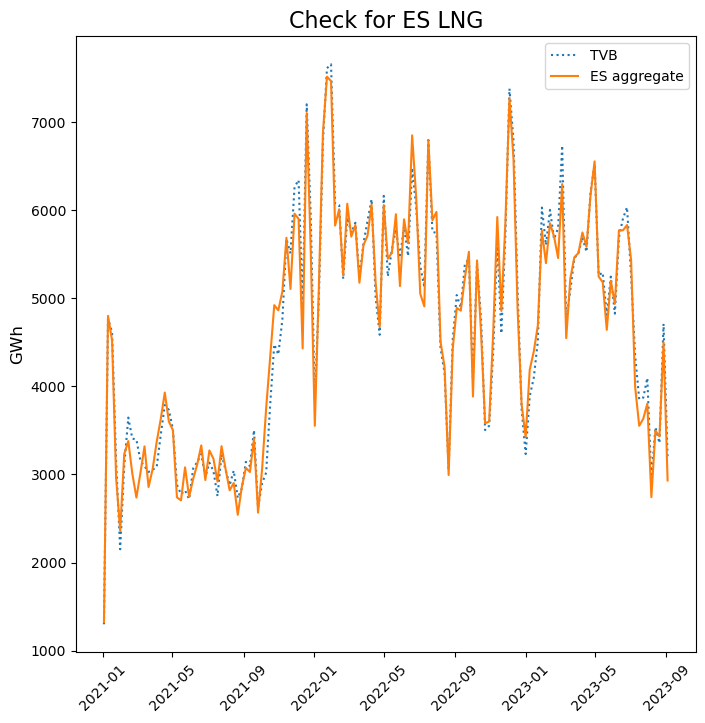

In [18]:
tvb = df[df['name']=='TVB (Virtual balancing LNG tank)']['2021':]
tvb_plot = tvb.groupby(pd.Grouper(freq='W'))['sendOut'].sum()
esp = df[df['country']=='ES']['2021':]
esp_plot = esp.groupby(pd.Grouper(freq='W'))['sendOut'].sum(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(tvb_plot,label='TVB',linestyle=':')
ax.plot(esp_plot,label='ES aggregate')

plt.xticks(rotation=45)
plt.title('Check for ES LNG',fontsize='16')
plt.ylabel('GWh',fontsize=12,loc='center')
plt.legend(loc='best')

In [16]:
df.country.unique()

array(['FR', 'IT', 'ES', 'LT', 'PL', 'NL', 'GB', 'BE', 'GR', 'PT', 'ES*',
       'GB*', 'HR', 'DE'], dtype=object)

In [17]:
# Change current directory
import os
os.chdir(Share_point)

In [18]:
df_C = df.groupby(['dates','country']).sum().reset_index()

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_12076\146117598.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_C = df.groupby(['dates','country']).sum().reset_index()


In [19]:
df_C = df_C.set_index(pd.DatetimeIndex(df_C['dates']))

## regassification % - Weekly data

In [20]:
from datetime import date
today = date.today()
last_obs = today - timedelta(days=2)
print(last_obs)
# enddate = datetime.strptime('2022-07-17', "%d-%m-%Y")
enddate = last_obs
startdate = enddate - timedelta(days=30)

2023-09-05


In [36]:
df_w = df_C.groupby([pd.Grouper(freq='W'),'country']).sum().reset_index()

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_29244\1569378660.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_w = df_C.groupby([pd.Grouper(freq='W'),'country']).sum().reset_index()


In [37]:
df_w=df_w.set_index(pd.DatetimeIndex(df_w['dates']))

In [38]:
df_w.country.unique()

array(['BE', 'ES', 'FR', 'GB', 'GR', 'IT', 'LT', 'NL', 'PL', 'PT', 'ES*',
       'GB*', 'HR', 'DE'], dtype=object)

In [39]:
df_w = df_w[~df_w.country.isin(['ES*','GB','GB*'])] # Get rid of UK and ES TVB aggregate for which there are no data pre-2020

In [40]:
del df_w['dates']

In [41]:
## Can change from new year
data = pd.DataFrame()
data['week'] = list(range(0,54,1))

# plot = df_w.groupby([pd.Grouper(freq='W'),'country']).sum()[:] ## use a converter if you want to transform the data
df_w['week'] = df_w.index.isocalendar().week

hist = df_w['2019-01-05':'2022-01-02'].groupby(['country','week']).mean().reset_index()
values2021 = df_w.loc['2019-12-28':'2022-01-02'].groupby(['country','week']).max().reset_index()
values2022 = df_w.loc['2022-01-03':'2023-01-01'].groupby(['country','week']).max().reset_index()
values2023 = df_w.loc['2023-01-01':'2023-12-31'].groupby(['country','week']).max().reset_index()

In [42]:
hist['regas %'] = (hist['sendOut']/hist['Max Sendout'])*100
values2021['regas %'] = (values2021['sendOut']/values2021['Max Sendout'])*100
values2022['regas %'] = (values2022['sendOut']/values2022['Max Sendout'])*100
values2023['regas %'] = (values2023['sendOut']/values2023['Max Sendout'])*100

In [43]:
import os
os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG')

In [44]:
Excelwriter = pd.ExcelWriter(r"GIE ALSI LNG terminals\LNG_GIE_weekly_data {}.xlsx".format(today),engine="xlsxwriter")
hist.to_excel(Excelwriter, sheet_name="2019-2021", index=False)
values2021.to_excel(Excelwriter, sheet_name="2021", index=False)
values2022.to_excel(Excelwriter, sheet_name="2022", index=False)
values2023.to_excel(Excelwriter, sheet_name="2023", index=False)
Excelwriter.close()
Excelwriter.save()

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_29244\1029837468.py:7: FutureWarning: save is not part of the public API, usage can give unexpected results and will be removed in a future version
  Excelwriter.save()
c:\Users\giovanni.sgaravatti\anaconda3\lib\site-packages\xlsxwriter\workbook.py:339: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


## LNG send  - Monthly

In [21]:
cplot = df.loc[~df['country'].str.startswith('GB')]

In [25]:
cplot_month =  cplot.groupby([pd.Grouper(freq='M'),'country']).sum(numeric_only=True).reset_index() #/converter

In [26]:
cmonth.country.unique()

array(['BE', 'ES', 'FR', 'GR', 'IT', 'LT', 'NL', 'PL', 'PT', 'ES*', 'HR',
       'DE'], dtype=object)

In [27]:
cplot_month['M3m'] = round(cplot_month['sendOut']/10.3,1)
print(cmonth.tail())

         dates country  sendOut   stored  Max Storage  Max Sendout    M3m
590 2023-09-30      IT   1604.1   870.21      1386.48       1680.9  155.7
591 2023-09-30      LT    292.6   350.88       500.19        349.2   28.4
592 2023-09-30      NL   1937.0  1794.52      2085.63       2304.6  188.1
593 2023-09-30      PL    599.6   380.65       960.00        660.0   58.2
594 2023-09-30      PT    415.7   950.26      1170.00        600.0   40.4


In [28]:
cmonth = pd.pivot_table(cplot_month,values='M3m',index='dates',columns='country')

In [39]:
cmonth= cmonth[:'2023-02']

In [46]:
cmonth.columns

Index(['BE', 'DE', 'ES', 'ES*', 'FR', 'GR', 'HR', 'IT', 'LT', 'NL', 'PL',
       'PT'],
      dtype='object', name='country')

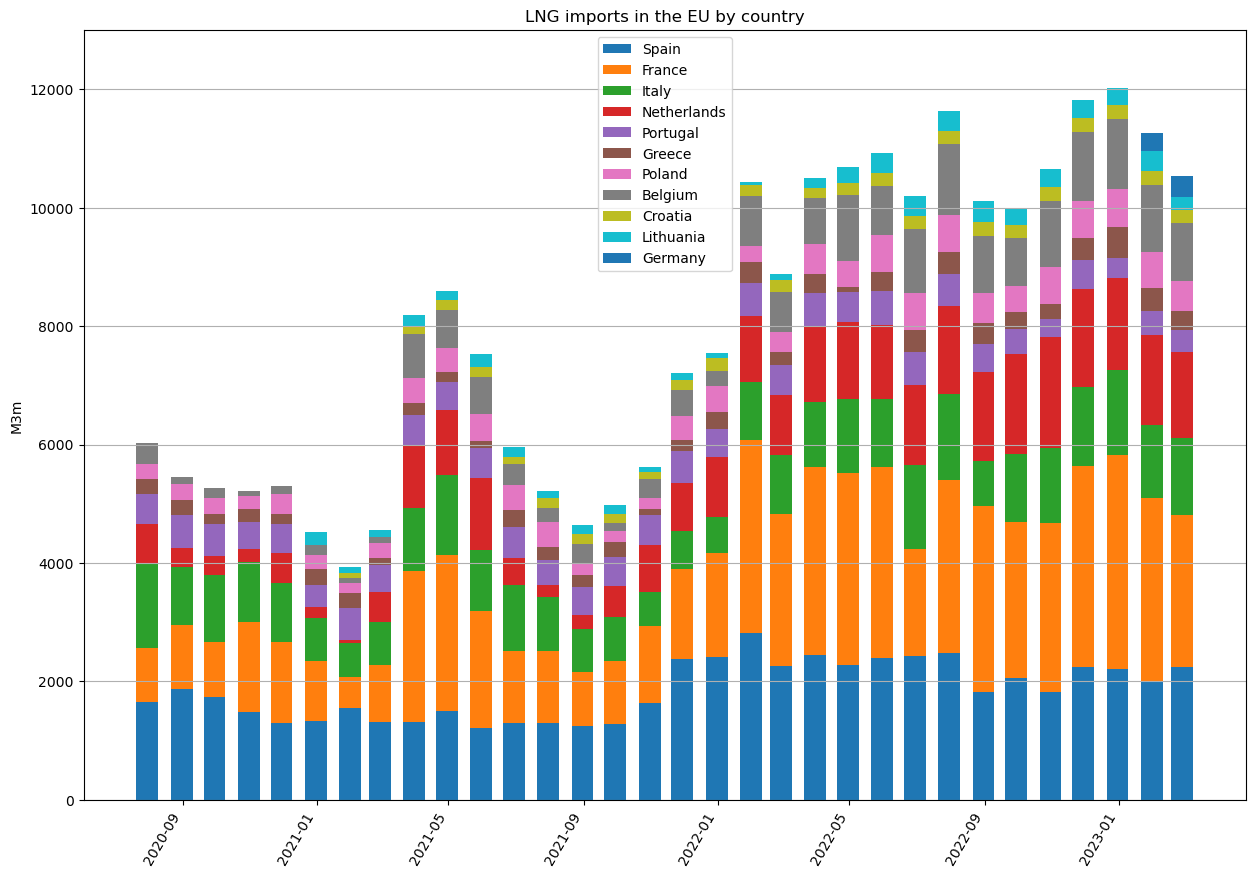

In [54]:
x = cmonth.index
width = 20       # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(15,10))

ax.bar(x, cmonth['ES*'], width, label='Spain')
ax.bar(x, cmonth['FR'], width, bottom=cmonth['ES*'],
       label='France')
ax.bar(x, cmonth['IT'], width, bottom=cmonth['ES*']+cmonth['FR'],
       label='Italy')
ax.bar(x, cmonth['NL'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT'],
       label='Netherlands')
ax.bar(x, cmonth['PT'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL'],
       label='Portugal')
ax.bar(x, cmonth['GR'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT'],
       label='Greece')
ax.bar(x, cmonth['PL'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR'],
       label='Poland')
ax.bar(x, cmonth['BE'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL'],
       label='Belgium')
ax.bar(x, cmonth['HR'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE'],
label='Croatia')
ax.bar(x, cmonth['LT'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE']+cmonth['HR'],
label='Lithuania')
ax.bar(x, cmonth['DE'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE']+cmonth['HR']+cmonth['LT'],
label='Germany')
fig.set_facecolor('white')

plt.setp(ax.get_xticklabels(), rotation=60, horizontalalignment='right')

ax = plt.gca()
ax.set_ylim([0, 13000])
ax.grid(axis='y')

ax.set_ylabel('M3m')
ax.set_title('LNG imports in the EU by country')
ax.legend()

plt.show()

Weekly

In [35]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\LNG terminals'

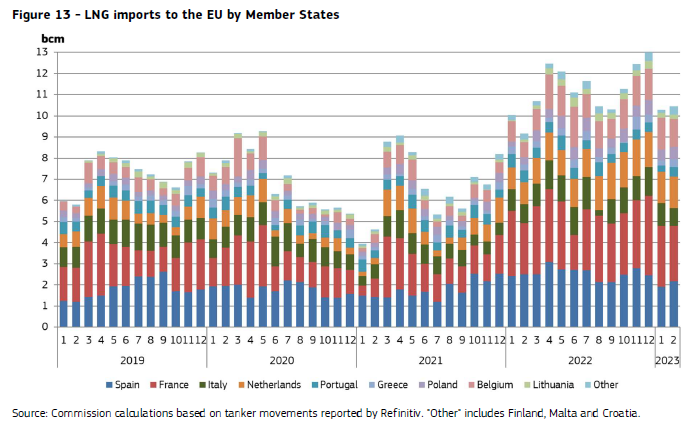

In [44]:
from IPython.display import Image, display
display(Image("Commission Qreport 2023.png",width=1200))

## LNG send outs - weekly (for the imports)

In [32]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\LNG terminals'

In [110]:
df.country.unique()

array(['BE', 'HR', 'FR', 'DE', 'GR', 'IT', 'LT', 'NL', 'PL', 'PT', 'ES',
       'GB', 'ES*', 'GB*'], dtype=object)

In [50]:
cplot.country.unique()

array(['ES', 'FR', 'IT', 'PT', 'NL', 'BE', 'GR', 'LT', 'PL', 'ES*', 'HR',
       'DE'], dtype=object)

In [189]:
cplot = df.loc[~df['country'].isin(['GB','GB*'])].reset_index() # getting rid of UK data 
cplot['dates'] = pd.to_datetime(cplot['dates'])  # Convert the date column to datetime

In [190]:
# to keep only TVB (Virtual balancing LNG tank) after July 2020
# TVB --> virtual balanging LNG for all country's terminals (country ES*)
# Filter the DataFrame to keep only specific names after July 2020
es_lng_points = ['Bilbao LNG Terminal', 'Cartagena LNG Terminal', 'Barcelona LNG Terminal', 'Mugardos LNG Terminal','Huelva LNG Terminal','Sagunto LNG Terminal']
date_threshold = pd.to_datetime('2020-07-09')
ccplot = cplot[~((cplot['name'].isin(es_lng_points)) & (cplot['dates'] >= date_threshold))]

In [192]:
ccplot[ccplot['country']=='ES']

,dates,sendOut,stored,Max Storage,Max Sendout,country,name
0,2015-03-07,35.7,100.40,300.00,115.2,ES,Mugardos LNG Terminal
3,2015-03-07,35.9,190.15,585.48,375.8,ES,Cartagena LNG Terminal
4,2015-03-07,88.3,75.66,448.83,222.7,ES,Bilbao LNG Terminal
8,2015-03-07,113.9,281.25,617.89,375.8,ES,Huelva LNG Terminal
11,2015-03-07,114.2,193.76,758.03,542.9,ES,Barcelona LNG Terminal
...,...,...,...,...,...,...,...
32033,2020-07-08,55.9,218.76,598.44,278.3,ES,Sagunto LNG Terminal
32039,2020-07-08,189.5,463.43,585.48,375.8,ES,Cartagena LNG Terminal
32042,2020-07-08,157.1,170.41,617.89,375.8,ES,Huelva LNG Terminal
32046,2020-07-08,51.6,130.03,300.00,115.2,ES,Mugardos LNG Terminal


In [193]:
es = ccplot[(ccplot['country']=='ES*')].index
# now change the country to 'ES' also for balancing point TVB
for i in es:
    ccplot.loc[i,'country']='ES'

# reset index
ccplot = ccplot.reset_index()
ccplot=ccplot.set_index(pd.DatetimeIndex(ccplot['dates']))
del ccplot['dates']

In [194]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\LNG terminals\\raw_data'

In [195]:
ccplot.to_csv('agsi.csv')

In [183]:
ccplot.country.unique()

array(['FR', 'IT', 'PT', 'NL', 'BE', 'GR', 'LT', 'PL', 'ES', 'HR', 'DE'],
      dtype=object)

In [34]:
cplot_week = cplot.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
cplot_week['week'] = cplot_week.index.isocalendar().week

In [35]:
cplot_week['M3m']=round(cplot_week['sendOut']/10.3,1)

In [37]:
cplot_week

,sendOut,stored,Max Storage,Max Sendout,week,M3m
dates,,,,,,
2015-03-08,1494.7,4822.92,12099.66,8974.8,10,145.1
2015-03-15,6573.9,15955.55,42348.81,31411.8,11,638.2
2015-03-22,8441.6,16134.85,42348.81,31411.8,12,819.6
2015-03-29,8573.1,15882.03,42348.81,31411.8,13,832.3
2015-04-05,7511.2,17142.37,41998.81,31155.3,14,729.2
...,...,...,...,...,...,...
2023-08-06,18870.1,25040.60,49637.70,38457.6,31,1832.0
2023-08-13,22413.2,33312.00,57910.65,44833.2,32,2176.0
2023-08-20,21440.9,35901.44,57910.65,44841.6,33,2081.6


<Axes: xlabel='dates'>

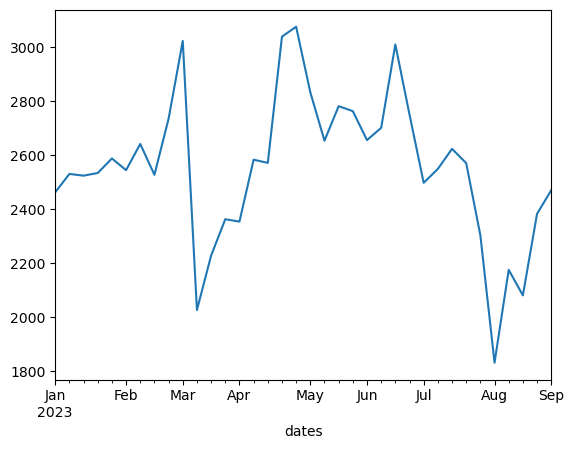

In [36]:
cplot_week['M3m']['2023':].plot()